In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_ind, ttest_1samp
from evaluations import *
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
from visualizations import flatmap_real_vals, plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from py_util_dx.data_utils import get_roi_vtx_from_fs32k
from scipy.spatial.distance import pdist

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}')

In [4]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [5]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal'] 
n_rois = len(ROIs) 
example_subjIs = np.arange(10)
n_example_subjects = len(example_subjIs) 
frames_dict = {
    'PFC': [[-210, 25, -90, 140], [0, 240, -110, 120]], 
    'visual': [[100, 230, -70, 160], [-250, -50, -70, 130]], 
    'somatosensory':[[-10, 80, -10, 160], [-60, 30, -10, 140]], 
    'parietal': [[20, 140, 0, 160], [-140, -30, 0, 160]]
}

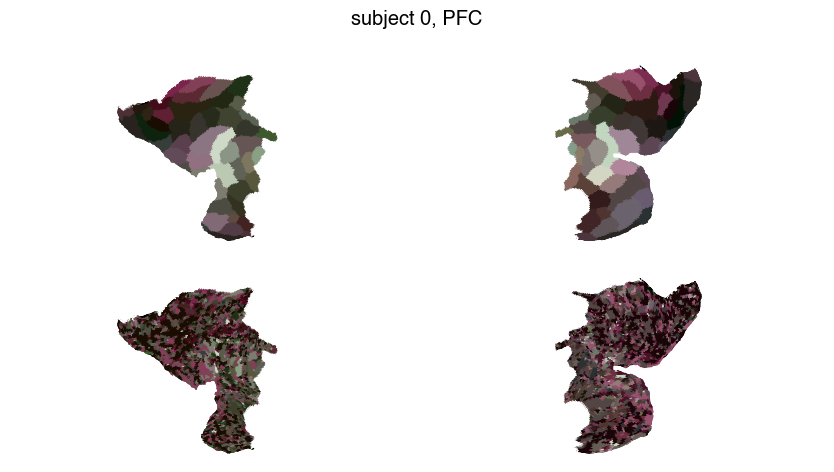

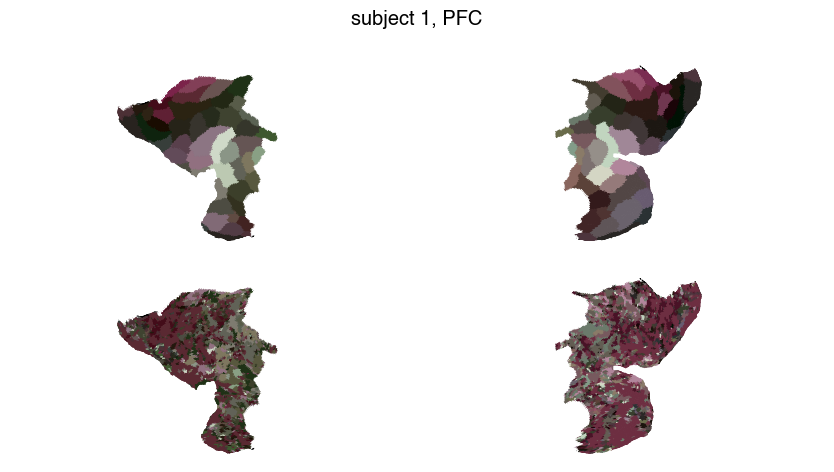

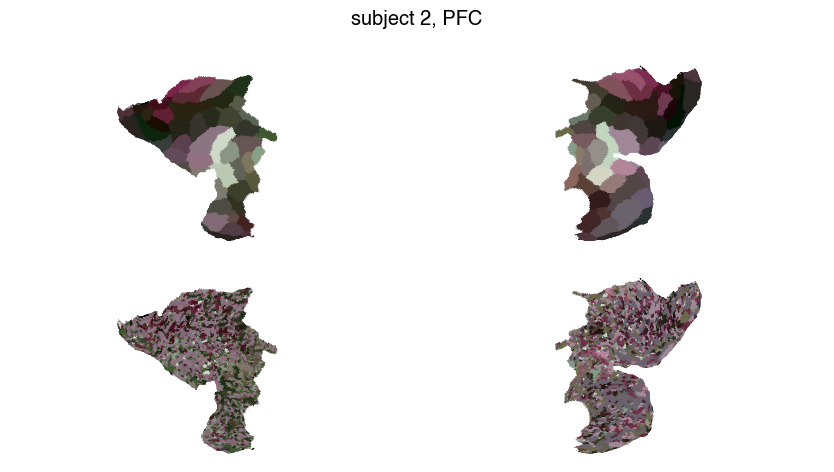

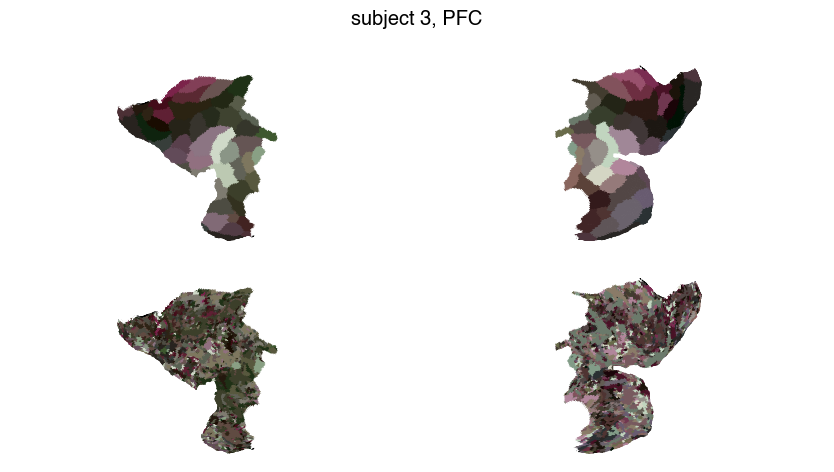

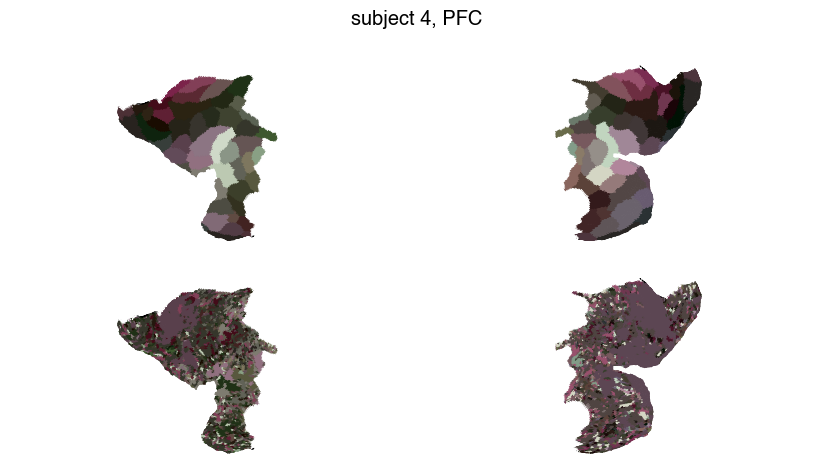

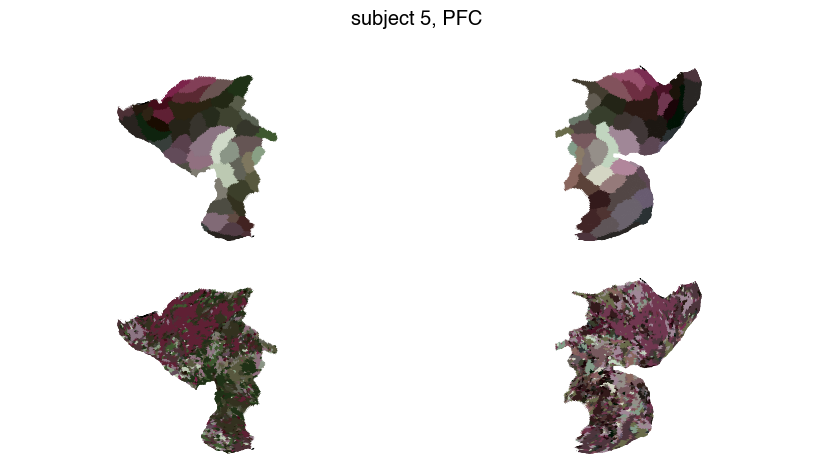

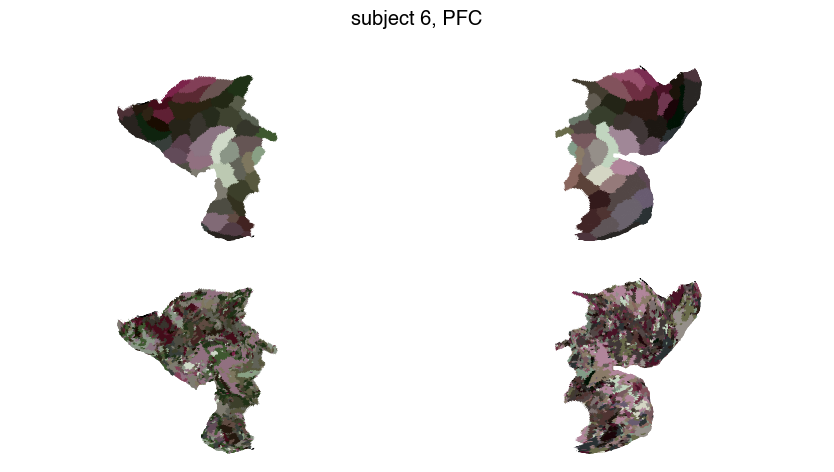

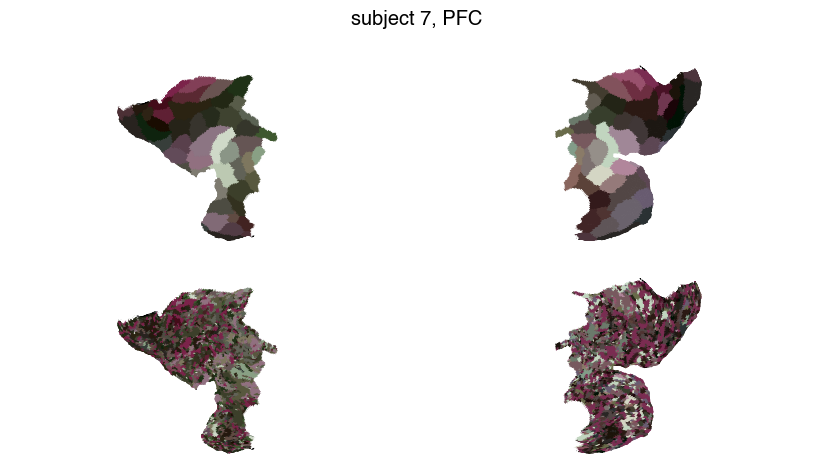

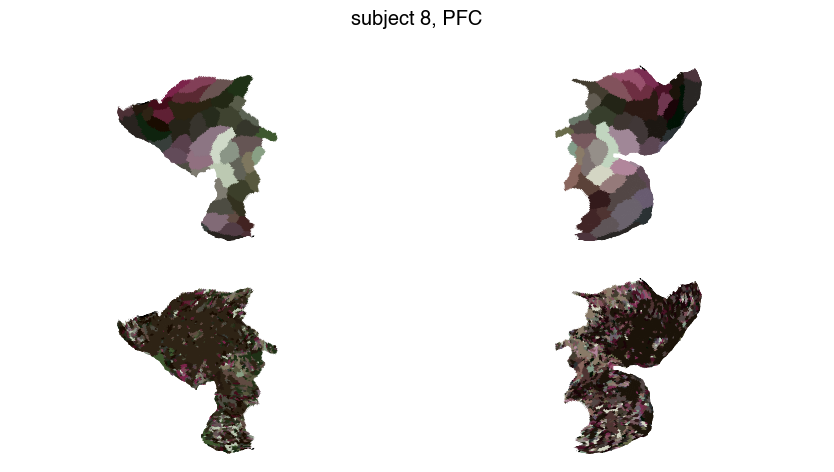

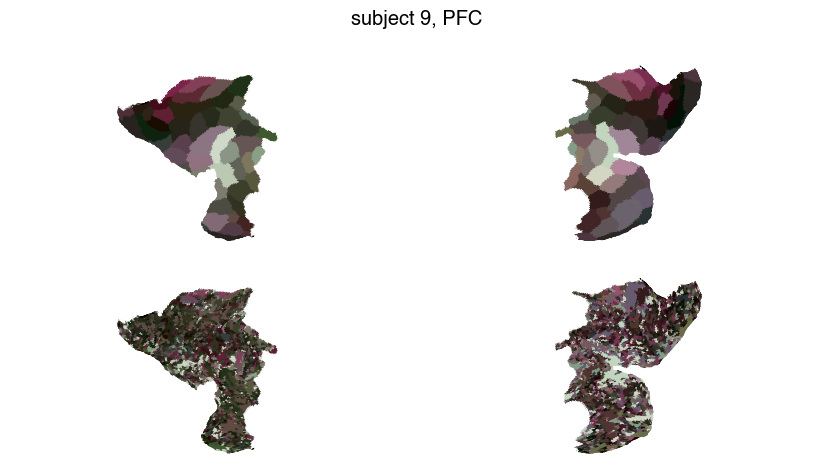

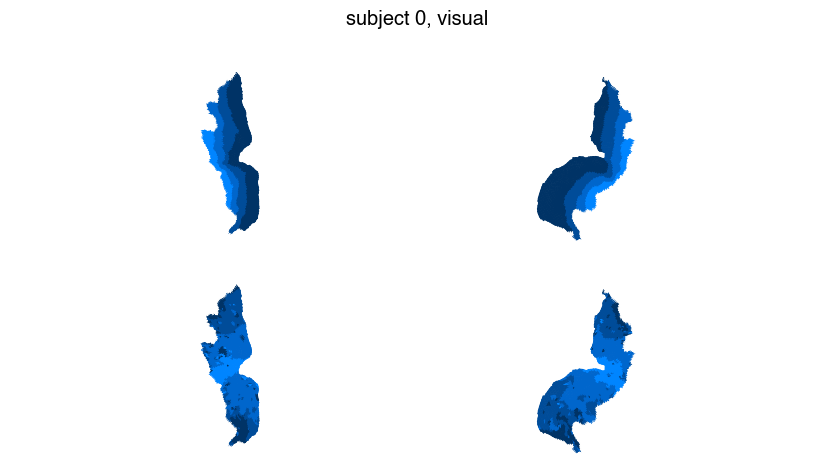

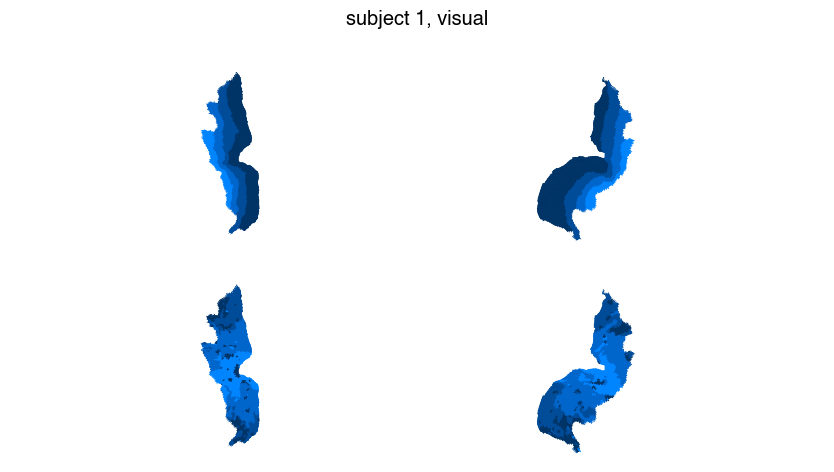

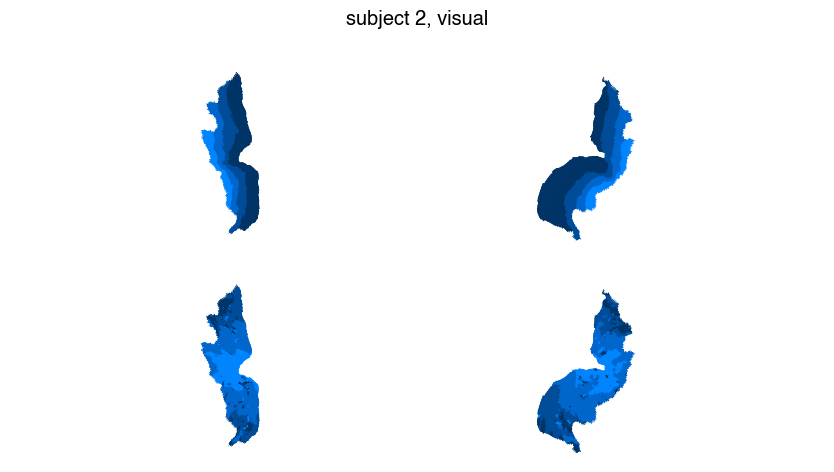

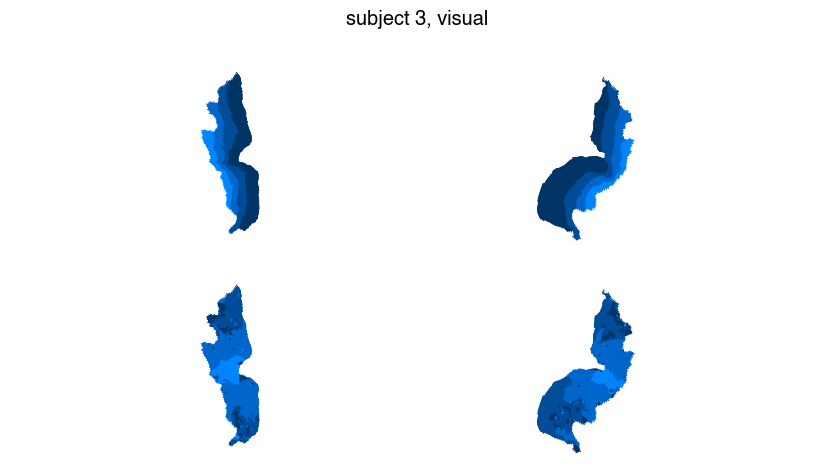

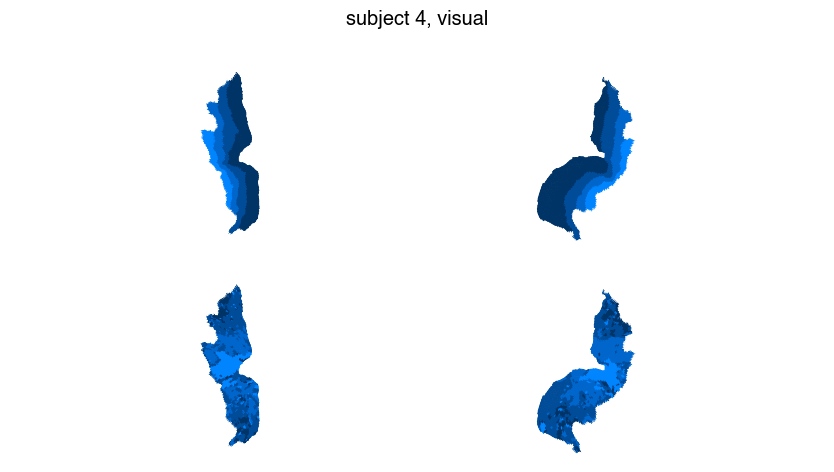

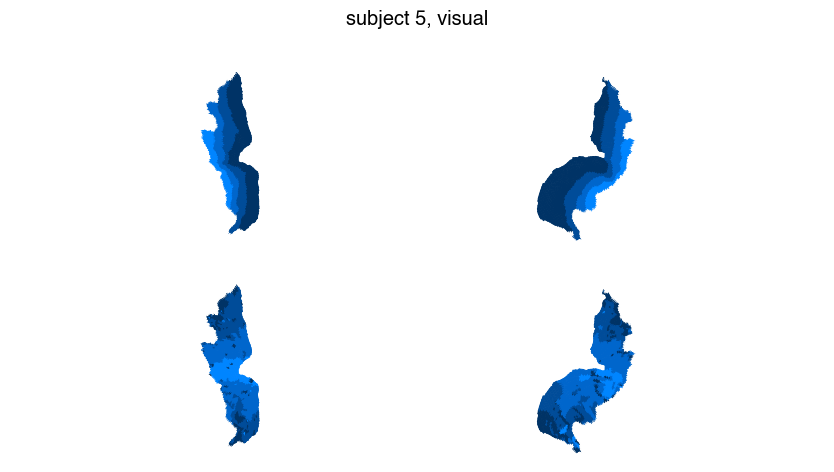

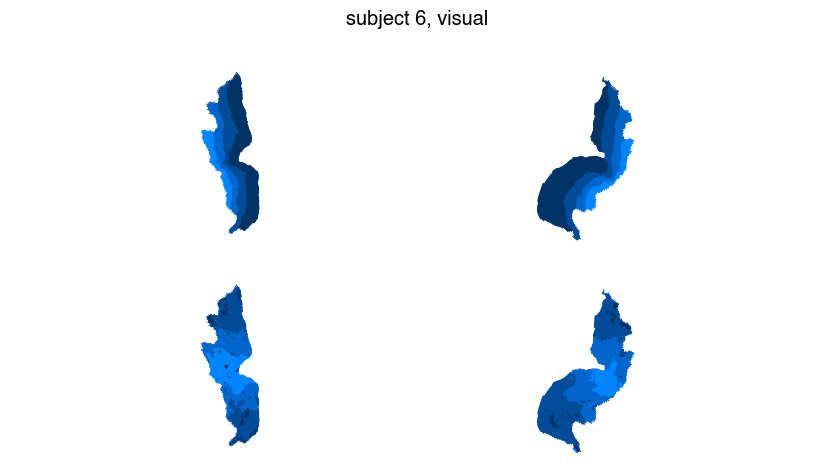

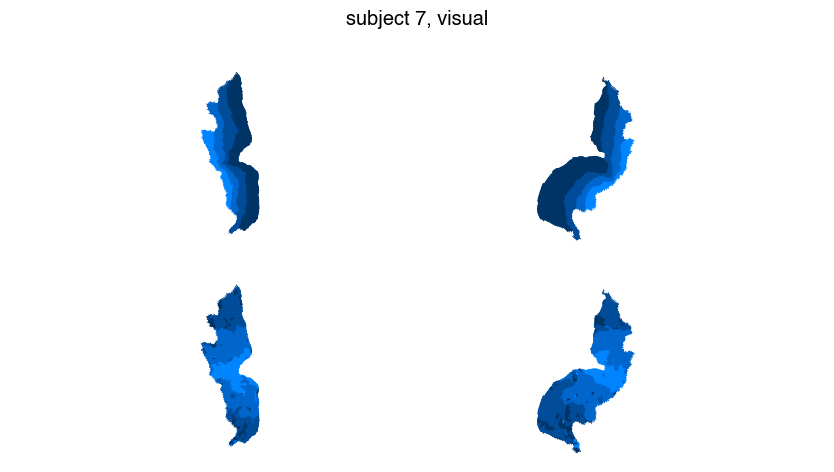

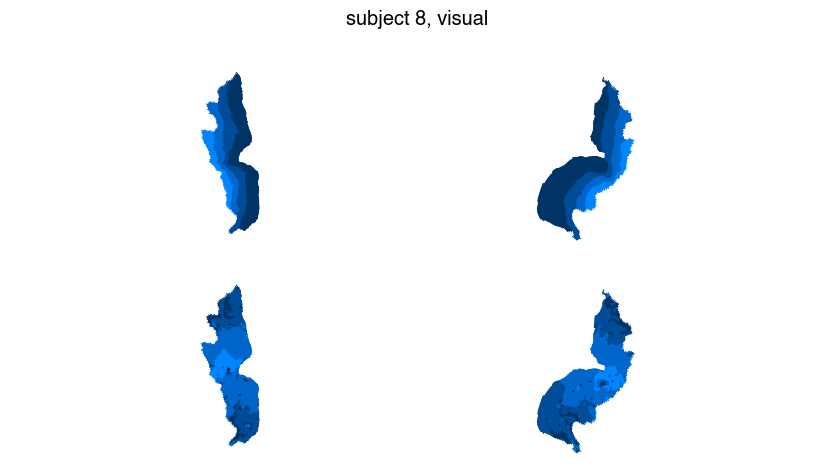

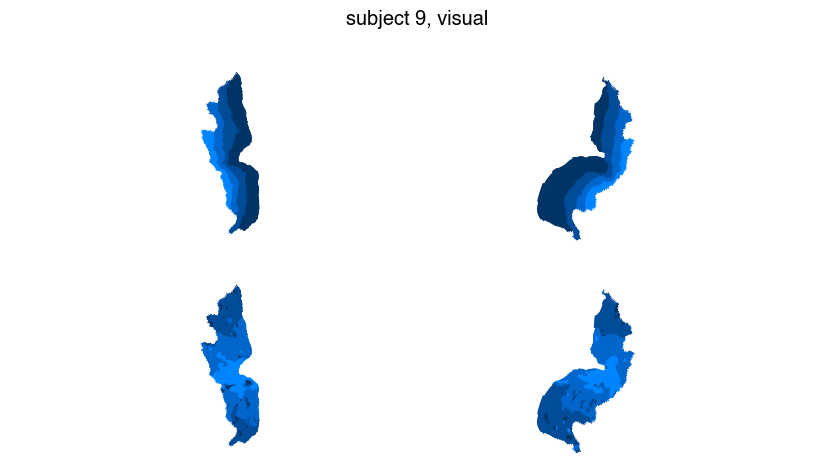

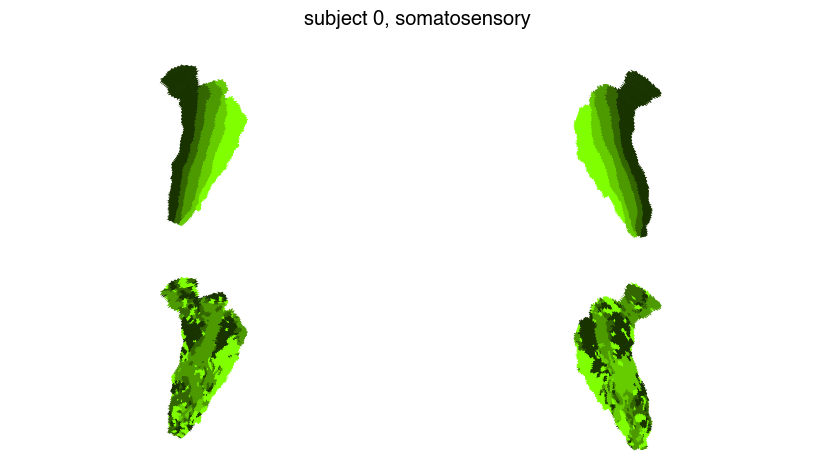

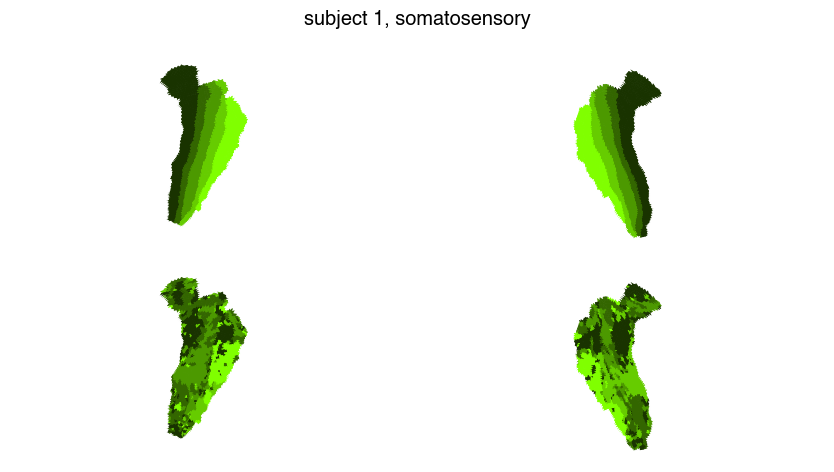

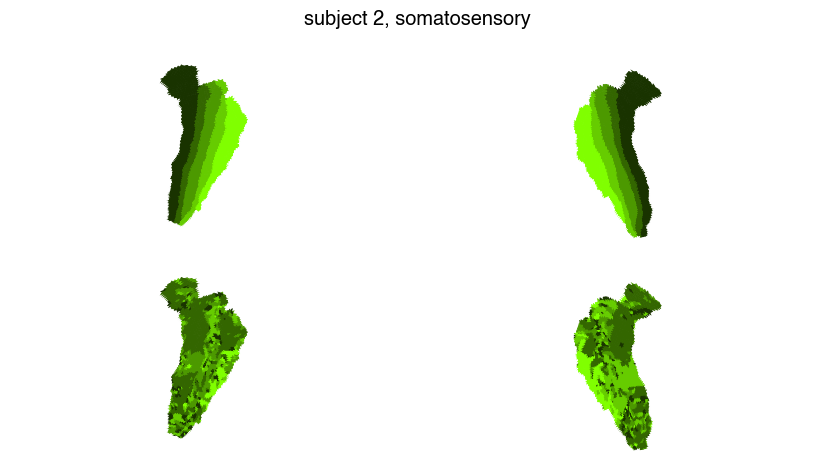

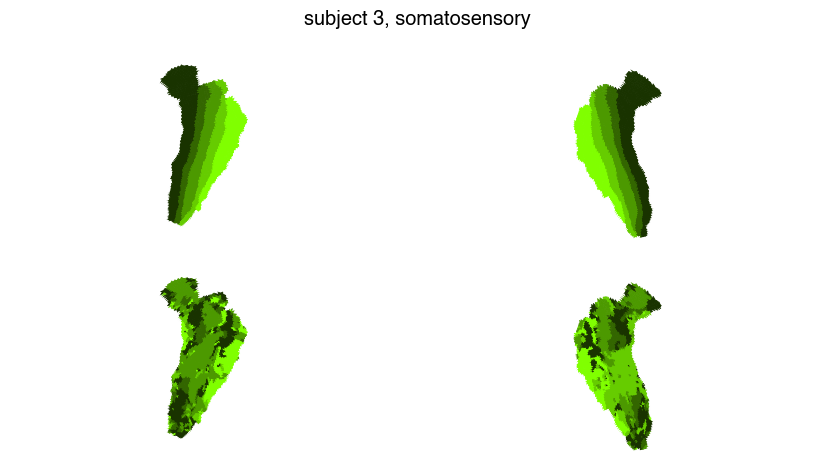

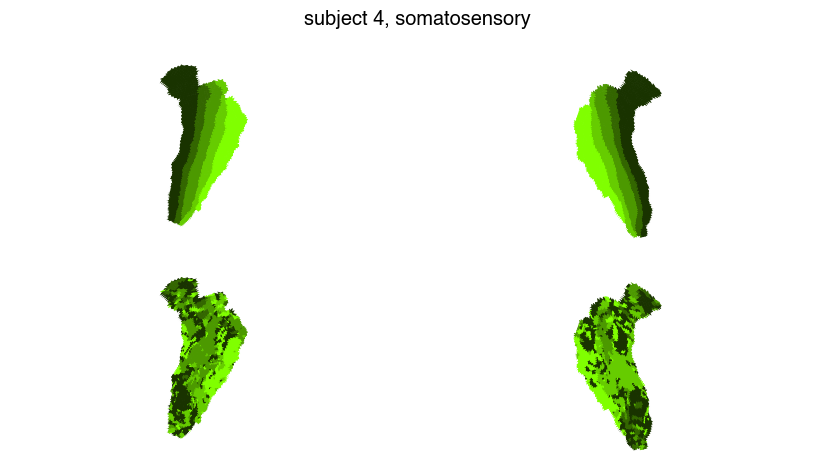

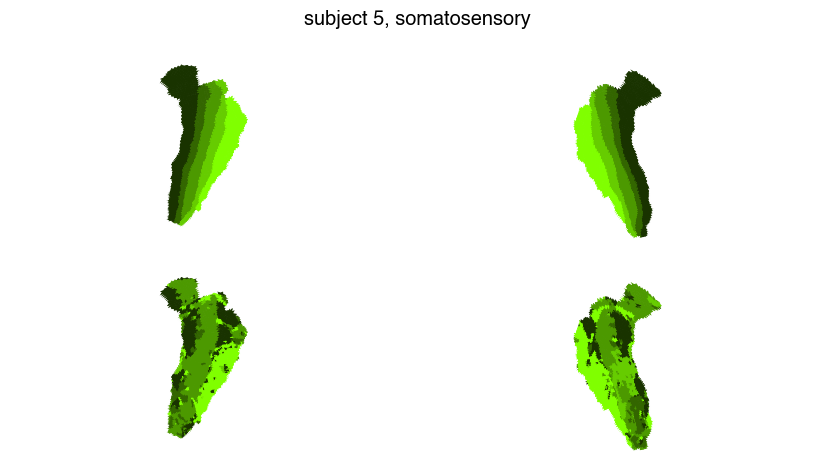

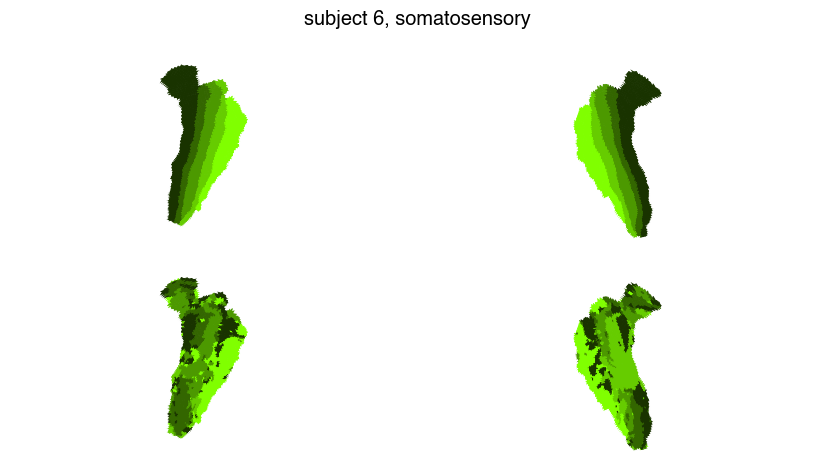

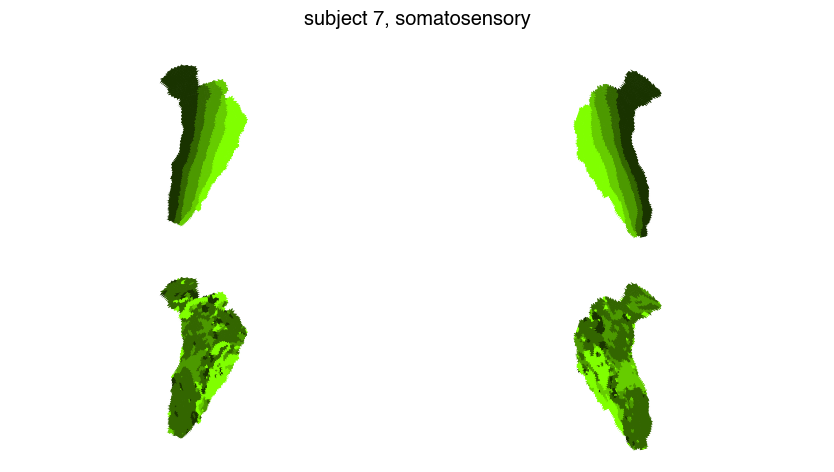

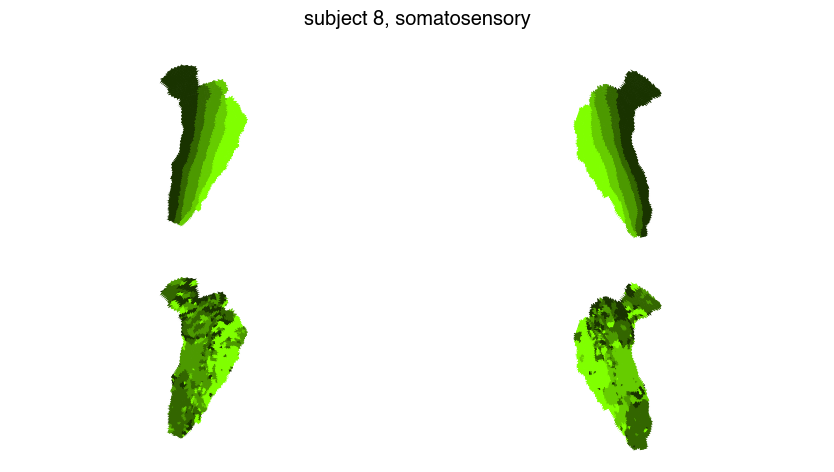

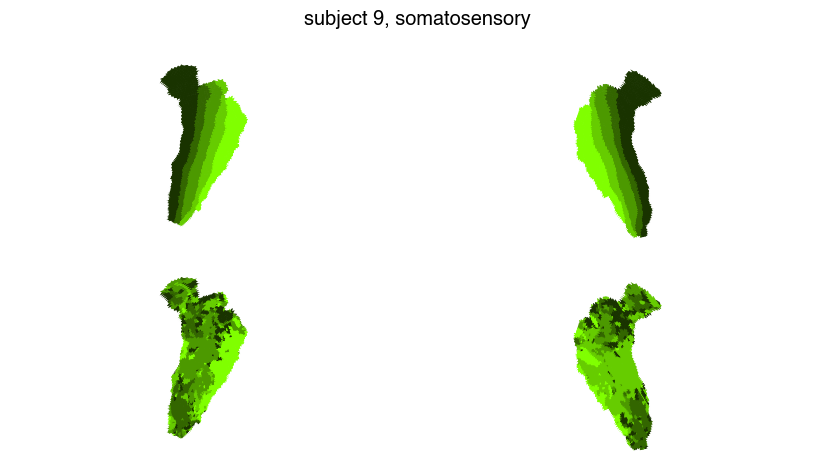

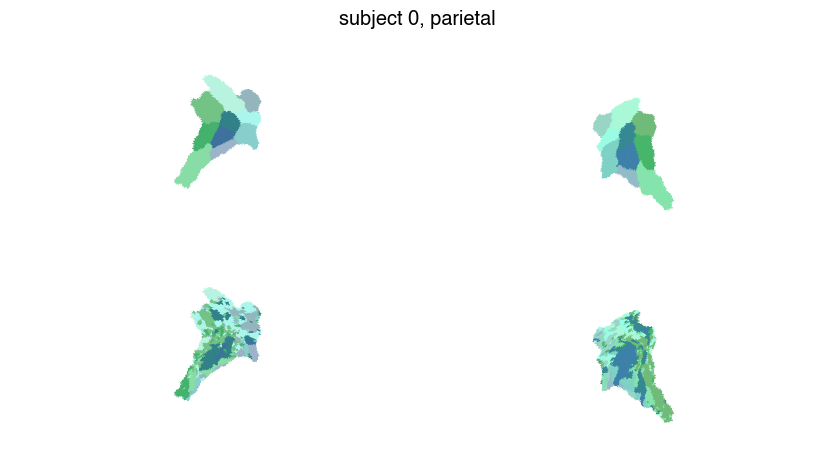

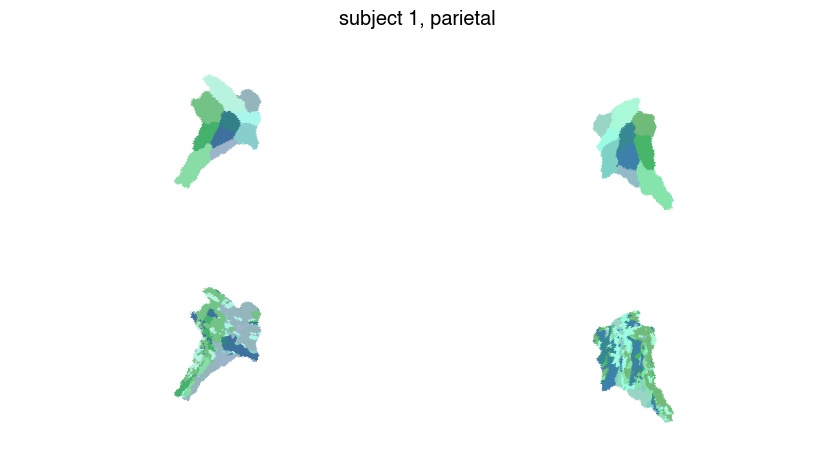

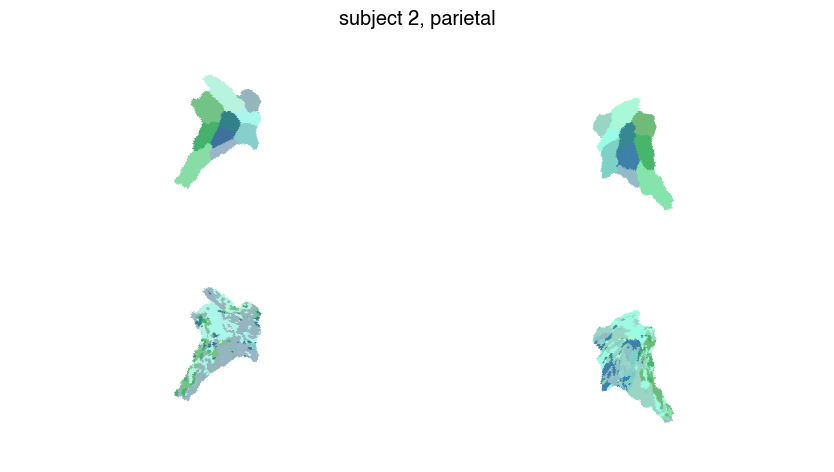

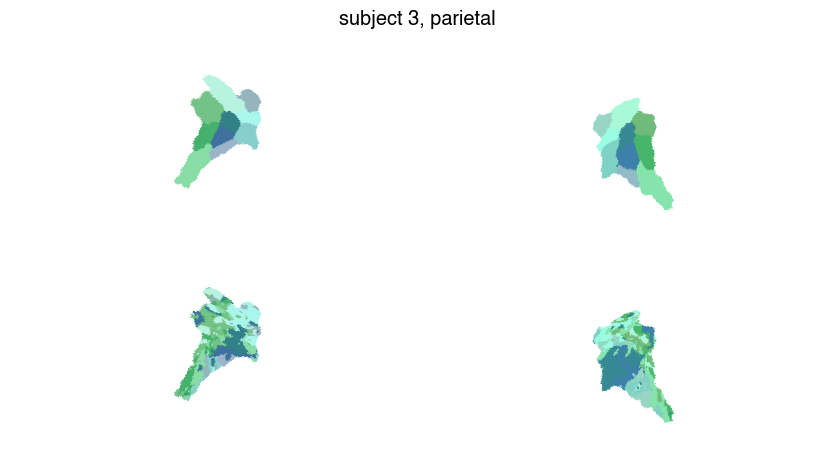

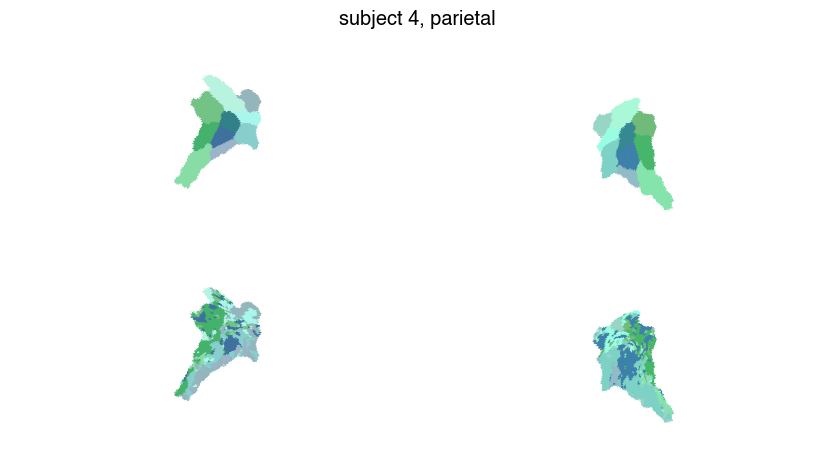

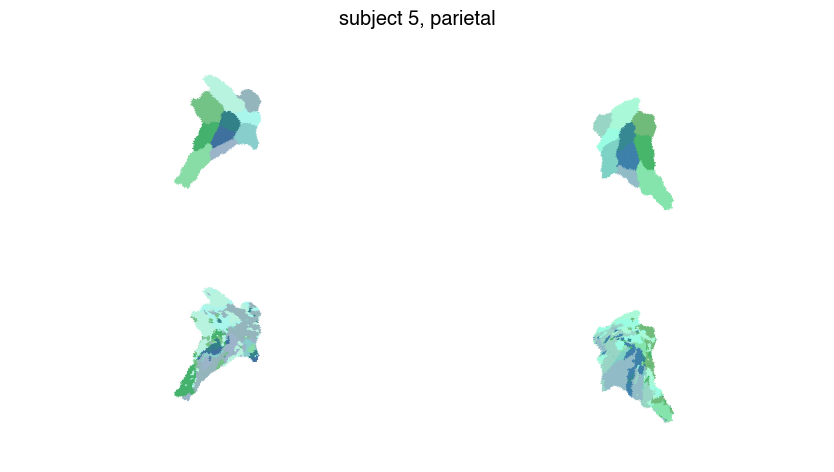

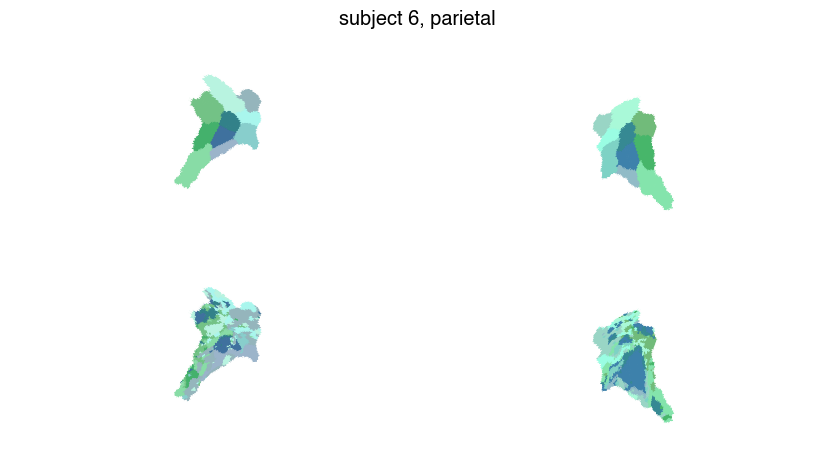

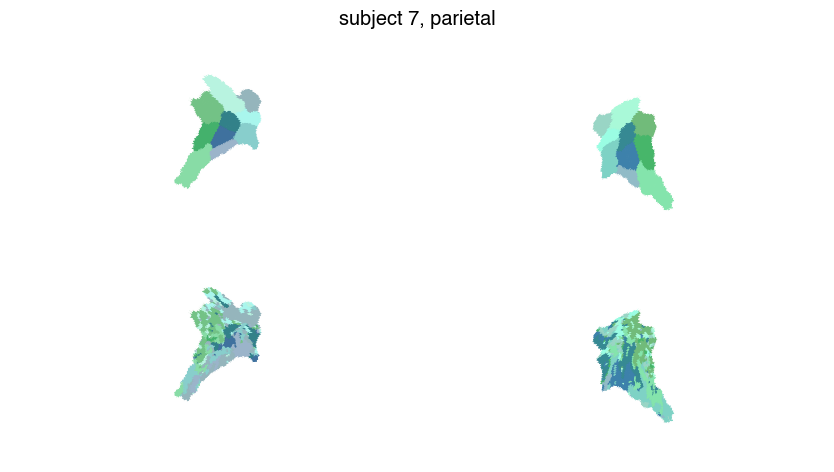

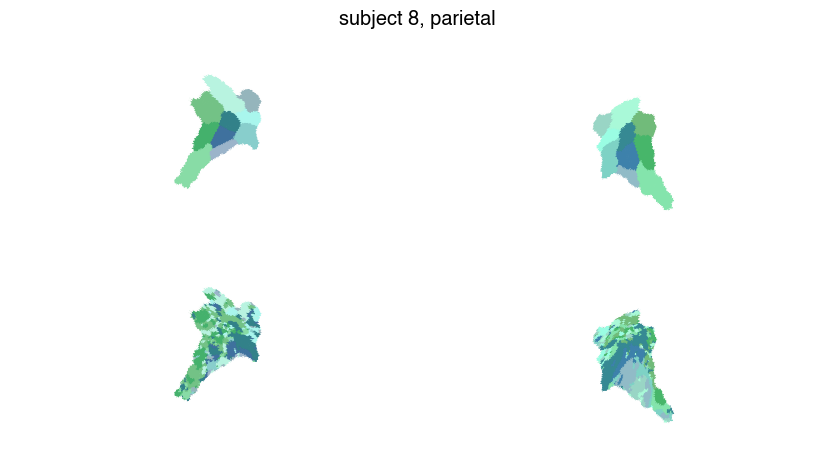

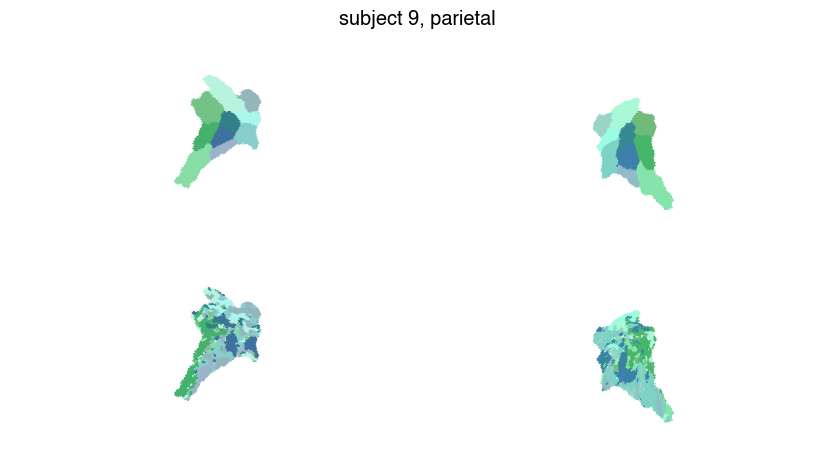

In [6]:
for roiI in np.arange(n_rois):
    PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', f'output_{ROIs[roiI]}.pkl')
    with open(PKL_individualized_parcellation, 'rb') as pf:
        output_indiv = pickle.load(pf)
        labels_in_glasser = output_indiv['labels_in_glasser']
        parcel_names_in_glasser = output_indiv['parcel_names_in_glasser']

        U_individual = output_indiv['U_individual']     # data only parcellation
        indiv_parcellation = output_indiv['indiv_parcellation']

        U_group = output_indiv['U_group']
        group_parcellation = output_indiv['group_parcellation']


    for subjI in example_subjIs:
        fig, ax = plt.subplots(2, 2)  
        fig.set_figwidth(full_width)

        # first plot group atlas 
        [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
        plt.axes(ax[0, 0])
        plot_flatmap_labels(label_L, 'L', frame=frames_dict[ROIs[roiI]][0], borders=None)

        plt.axes(ax[0, 1])
        plot_flatmap_labels(label_R, 'R', frame=frames_dict[ROIs[roiI]][1], borders=None)

        [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[subjI].reshape(1, -1)))
        plt.axes(ax[1, 0])
        plot_flatmap_labels(label_L, 'L', frame=frames_dict[ROIs[roiI]][0], borders=None) 
        # plot_flatmap_labels(label_L, 'L', frame=None, borders=None) 
        
        plt.axes(ax[1, 1])
        plot_flatmap_labels(label_R, 'R', frame=frames_dict[ROIs[roiI]][1], borders=None)  
        # plot_flatmap_labels(label_R, 'R', frame=None, borders=None)  

        plt.suptitle(f'subject {subjI}, {ROIs[roiI]}')
        plt.tight_layout() 

        JPG_fig = os.path.join(resultsPath, f'example_atlas_{ROIs[roiI]}_subject_{subjI}.jpg')
        plt.savefig(JPG_fig, dpi=500, format='jpg')